<a href="https://colab.research.google.com/github/ElielSf/telecomx-br-pt2/blob/main/TelecomX_BR_pt2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extração e Transformação de Dados

In [233]:
import pandas as pd

Importando os dados

In [234]:
df = pd.read_csv("https://raw.githubusercontent.com/ElielSf/telecomx-br-pt2/refs/heads/main/dados_limpos_telecomx_br.csv")

Conhecendo o dataset

In [235]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7032 non-null   object 
 1   churn                 7032 non-null   object 
 2   genero                7032 non-null   object 
 3   idoso                 7032 non-null   object 
 4   conjuge               7032 non-null   object 
 5   dependentes           7032 non-null   object 
 6   meses_contrato        7032 non-null   int64  
 7   telefone              7032 non-null   object 
 8   multiplas_linhas      7032 non-null   object 
 9   internet              7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes     

In [236]:
print("Cardinalidade de cada coluna:")
print(df.nunique().sort_values(ascending=False))

Cardinalidade de cada coluna:
id_cliente              7032
cobranca_total          6530
cobranca_mensal         1584
contas_diarias           321
meses_contrato            72
metodo_pagamento           4
streaming_filmes           3
suporte_tecnico            3
backup_online              3
protecao_dispositivo       3
streaming_tv               3
multiplas_linhas           3
internet                   3
seguranca_online           3
contrato                   3
dependentes                2
idoso                      2
genero                     2
churn                      2
conjuge                    2
telefone                   2
fatura_digital             2
dtype: int64


In [237]:
print("\nColunas com apenas 1 valor único (variância zero):")
print(df.columns[df.nunique() == 1].tolist())


Colunas com apenas 1 valor único (variância zero):
[]


Verificando correlação

In [238]:
correlacao = df['contas_diarias'].corr(df['cobranca_mensal'])
print(f"Correlação entre contas_diarias e cobranca_mensal: {correlacao:.4f}")

Correlação entre contas_diarias e cobranca_mensal: 1.0000


Removendo colunas

In [239]:
colunas_para_remover = [
    'id_cliente',       # identificador único — sem valor preditivo
    'contas_diarias',   # derivada de cobranca_mensal — redundante
]

df = df.drop(columns=colunas_para_remover)

print(f"Shape após remoção: {df.shape}")

Shape após remoção: (7032, 20)


In [240]:
df

,churn,genero,idoso,conjuge,dependentes,meses_contrato,telefone,multiplas_linhas,internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,contrato,fatura_digital,metodo_pagamento,cobranca_mensal,cobranca_total
0,Não,Mulher,Não,Sim,Sim,9,Sim,Não,DSL,Não,Sim,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30
1,Não,Homem,Não,Não,Não,9,Sim,Sim,DSL,Não,Não,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40
2,Sim,Homem,Não,Não,Não,4,Sim,Não,Fibra óptica,Não,Não,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85
3,Sim,Homem,Sim,Sim,Não,13,Sim,Não,Fibra óptica,Não,Sim,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85
4,Sim,Mulher,Sim,Sim,Não,3,Sim,Não,Fibra óptica,Não,Não,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,Não,Mulher,Não,Não,Não,13,Sim,Não,DSL,Sim,Não,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90
7028,Sim,Homem,Não,Sim,Não,22,Sim,Sim,Fibra óptica,Não,Não,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70
7029,Não,Homem,Não,Não,Não,2,Sim,Não,DSL,Não,Sim,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75
7030,Não,Homem,Não,Sim,Sim,67,Sim,Não,DSL,Sim,Não,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65


Verificando valores únicos

In [241]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")

churn: ['Não' 'Sim']
genero: ['Mulher' 'Homem']
idoso: ['Não' 'Sim']
conjuge: ['Sim' 'Não']
dependentes: ['Sim' 'Não']
telefone: ['Sim' 'Não']
multiplas_linhas: ['Não' 'Sim' 'Sem serviço de telefone']
internet: ['DSL' 'Fibra óptica' 'Não']
seguranca_online: ['Não' 'Sim' 'Sem serviço de internet']
backup_online: ['Sim' 'Não' 'Sem serviço de internet']
protecao_dispositivo: ['Não' 'Sim' 'Sem serviço de internet']
suporte_tecnico: ['Sim' 'Não' 'Sem serviço de internet']
streaming_tv: ['Sim' 'Não' 'Sem serviço de internet']
streaming_filmes: ['Não' 'Sim' 'Sem serviço de internet']
contrato: ['Anual' 'Mensal' 'Bienal']
fatura_digital: ['Sim' 'Não']
metodo_pagamento: ['Cheque enviado' 'Cheque eletrônico' 'Cartão de crédito'
 'Transferência bancária']


Encoding

In [242]:
mapa_binario = {'Sim': 1, 'Não': 0, 'Mulher': 1, 'Homem': 0}

colunas_binarias = [
    'genero', 'idoso', 'conjuge', 'dependentes',
    'telefone', 'fatura_digital', 'churn'
]

df[colunas_binarias] = df[colunas_binarias].replace(mapa_binario)

df = df.rename(columns={'genero': 'feminino'})

/tmp/ipykernel_218/691457800.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[colunas_binarias] = df[colunas_binarias].replace(mapa_binario)


In [243]:
colunas_nominais = [
    'multiplas_linhas', 'internet', 'seguranca_online',
    'backup_online', 'protecao_dispositivo', 'suporte_tecnico',
    'streaming_tv', 'streaming_filmes', 'contrato', 'metodo_pagamento'
]

# Converte colunas com 3 ou mais valores em colunas separadas, removendo a primeira
df = pd.get_dummies(df, columns=colunas_nominais, drop_first=True)

Convertendo de bool para int

In [244]:
# Converte bool em int
df = df.astype({col: int for col in df.select_dtypes('bool').columns})

In [245]:
df

,churn,feminino,idoso,conjuge,dependentes,meses_contrato,telefone,fatura_digital,cobranca_mensal,cobranca_total,...,suporte_tecnico_Sim,streaming_tv_Sem serviço de internet,streaming_tv_Sim,streaming_filmes_Sem serviço de internet,streaming_filmes_Sim,contrato_Bienal,contrato_Mensal,metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária
0,0,1,0,1,1,9,1,1,65.60,593.30,...,1,0,1,0,0,0,0,0,1,0
1,0,0,0,0,0,9,1,0,59.90,542.40,...,0,0,0,0,1,0,1,0,1,0
2,1,0,0,0,0,4,1,1,73.90,280.85,...,0,0,0,0,0,0,1,1,0,0
3,1,0,1,1,0,13,1,1,98.00,1237.85,...,0,0,1,0,1,0,1,1,0,0
4,1,1,1,1,0,3,1,1,83.90,267.40,...,1,0,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,1,0,0,0,13,1,0,55.15,742.90,...,1,0,0,0,0,0,0,0,1,0
7028,1,0,0,1,0,22,1,1,85.10,1873.70,...,0,0,0,0,1,0,1,1,0,0
7029,0,0,0,0,0,2,1,1,50.30,92.75,...,0,0,0,0,0,0,1,0,1,0
7030,0,0,0,1,1,67,1,0,67.85,4627.65,...,1,0,0,0,1,1,0,0,1,0


In [246]:
print(f"Shape final: {df.shape}")
print(f"\nTipos restantes:\n{df.dtypes.value_counts()}")
print(f"\nColunas object: {df.select_dtypes('object').columns.tolist()}")

Shape final: (7032, 31)

Tipos restantes:
int64      29
float64     2
Name: count, dtype: int64

Colunas object: []


In [247]:
df.shape

(7032, 31)

Proporção de churn no dataset

In [248]:
print("Clientes que deixaram a empresa x Clientes ativos:")
print(f"{round(df['churn'].value_counts(normalize=True) * 100, 2)[1]}% x {round(df['churn'].value_counts(normalize=True) * 100, 2)[0]}%")

Clientes que deixaram a empresa x Clientes ativos:
26.58% x 73.42%


### Existe um **desequilibrio moderado**, impossibilitando o uso da métrica de acurácia com confiança pois o modelo pode chutar e acertar na maior parte das vezes.

In [249]:
import matplotlib.pyplot as plt
import seaborn as sns

Matriz de correlação

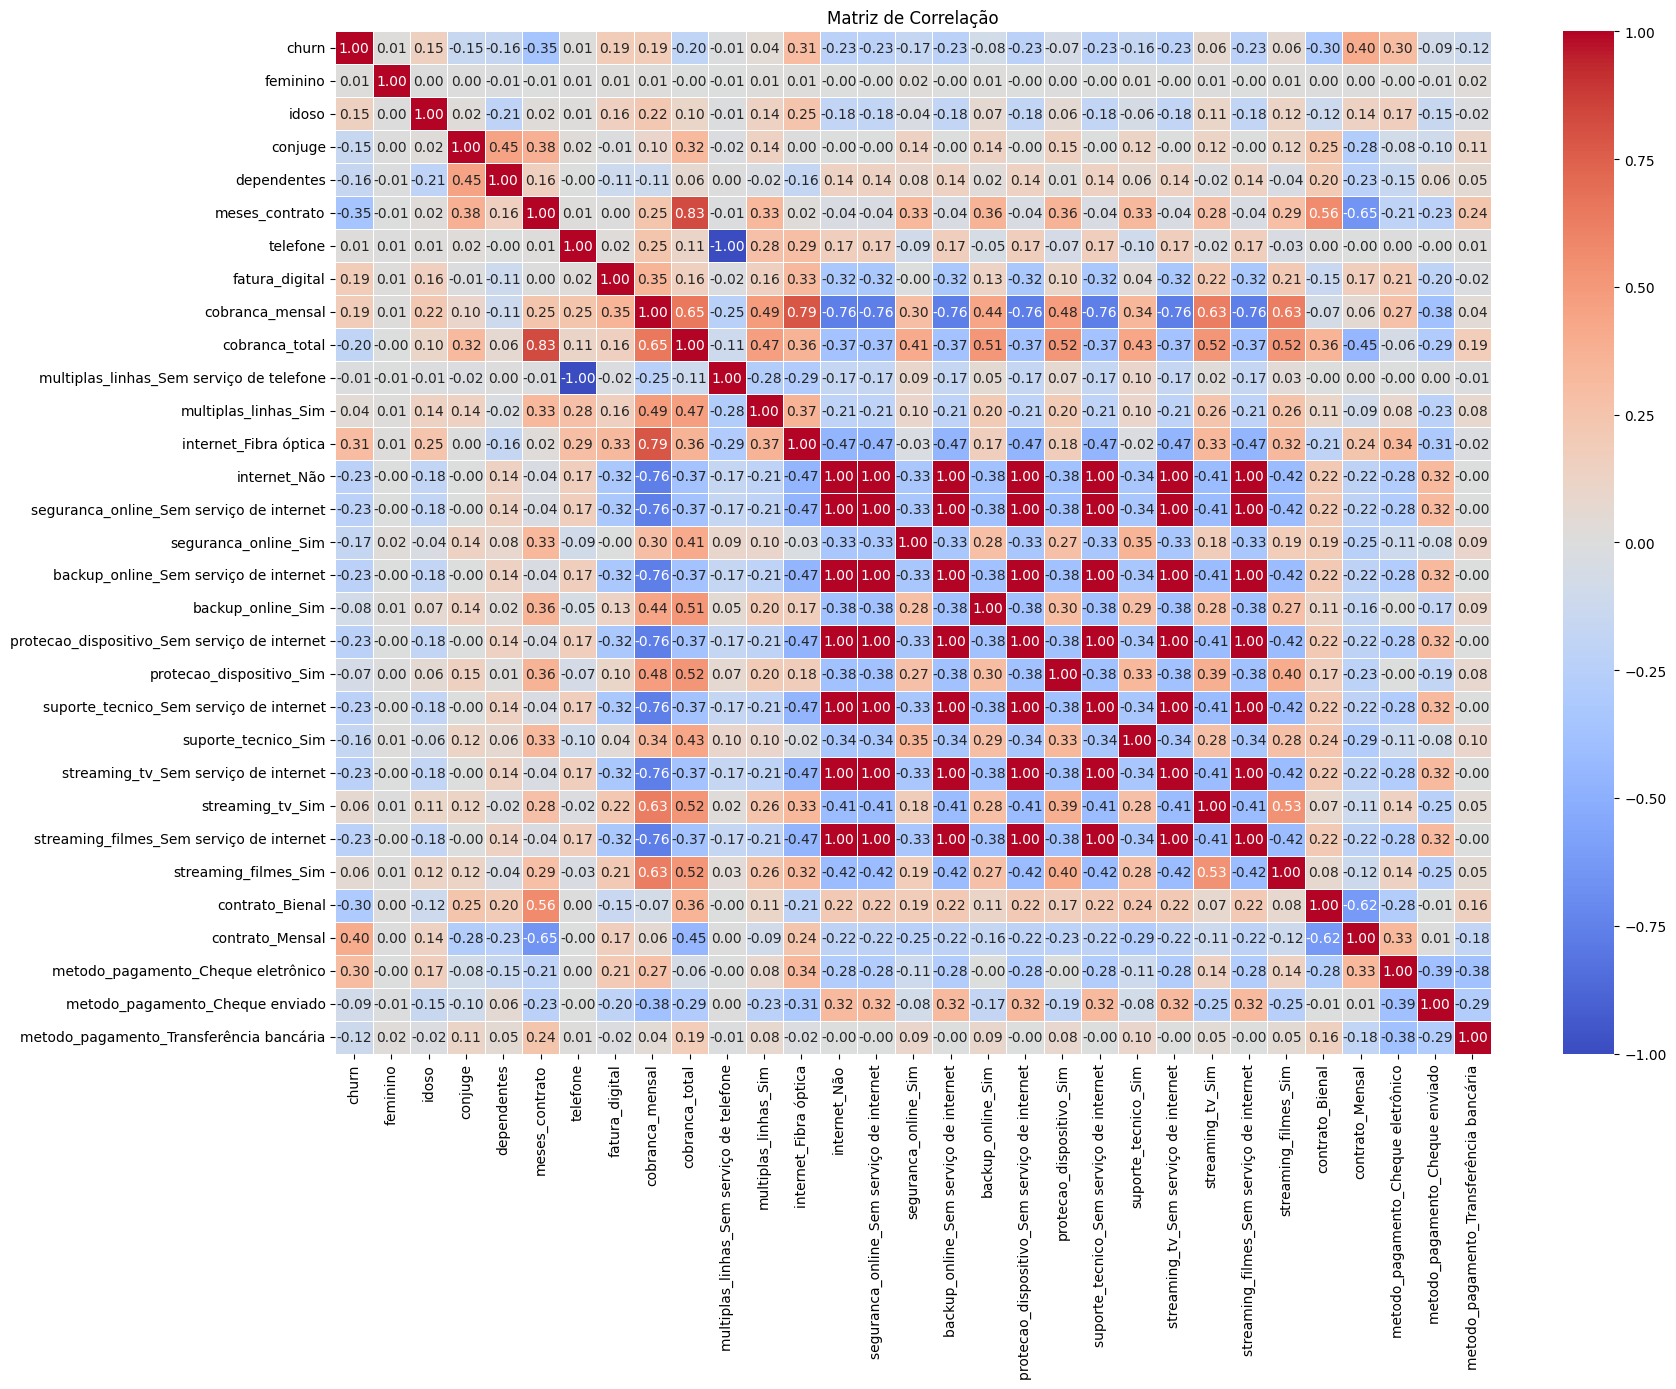

In [250]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Matriz de Correlação')
plt.tight_layout()
plt.show()

### Clientes com **menos tempo de contrato** e com **plano mensal** são os que apresentam **maior risco de evasão**. Contratos longos e fidelidade ao longo do tempo são fatores de proteção contra o churn.

Boxplot de tempo de contrato

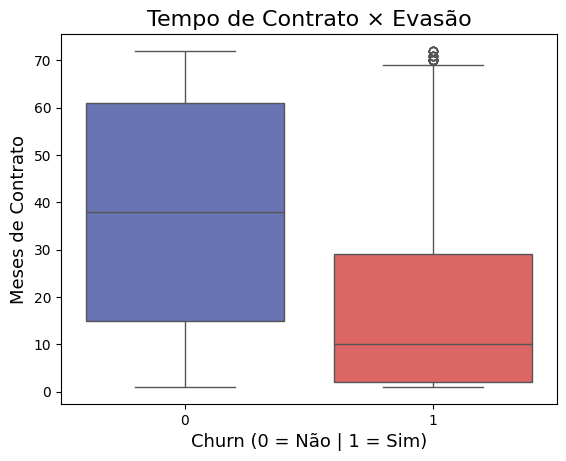

In [251]:
sns.boxplot(
    data=df,
    x='churn',
    y='meses_contrato',
    hue='churn',
    palette={0: '#5c6bc0', 1: '#ef5350'},
    legend=False
)

plt.title('Tempo de Contrato × Evasão', fontsize=16)
plt.xlabel('Churn (0 = Não | 1 = Sim)', fontsize=13)
plt.ylabel('Meses de Contrato', fontsize=13)
plt.show()

Boxplot de total gasto

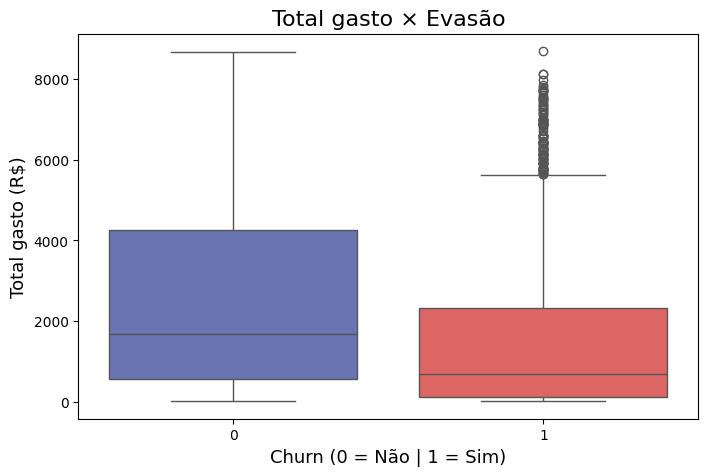

In [252]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='churn',
    y='cobranca_total',
    hue='churn',
    palette={0: '#5c6bc0', 1: '#ef5350'},
    legend=False
)

plt.title('Total gasto × Evasão', fontsize=16)
plt.xlabel('Churn (0 = Não | 1 = Sim)', fontsize=13)
plt.ylabel('Total gasto (R$)', fontsize=13)
plt.show()

Scatteplot de evasão

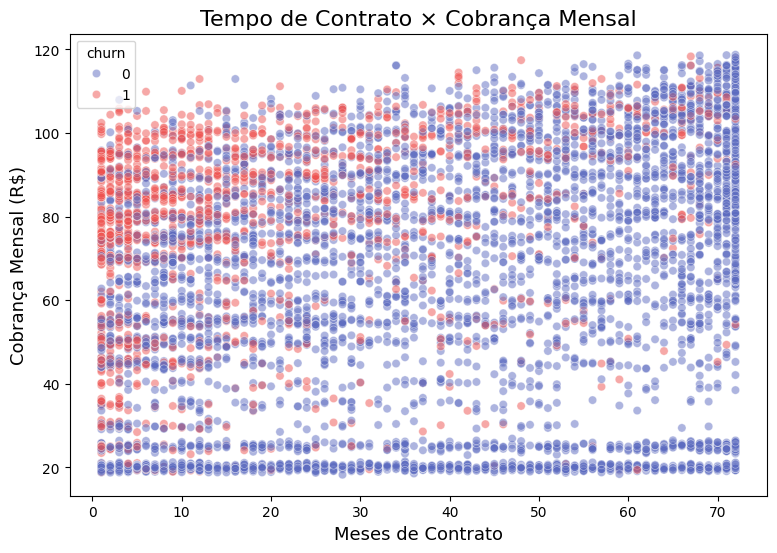

In [253]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='meses_contrato',
    y='cobranca_mensal',
    hue='churn',
    palette={0: '#5c6bc0', 1: '#ef5350'},
    alpha=0.5
)

plt.title('Tempo de Contrato × Cobrança Mensal', fontsize=16)
plt.xlabel('Meses de Contrato', fontsize=13)
plt.ylabel('Cobrança Mensal (R$)', fontsize=13)
plt.show()

Scatteplot dos clientes que evadiram

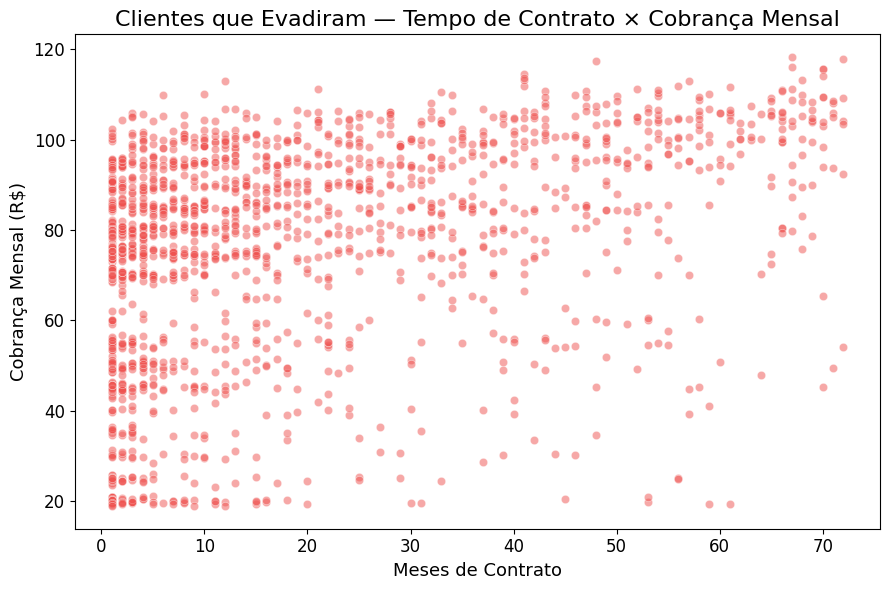

In [254]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df[df['churn'] == 1],
    x='meses_contrato',
    y='cobranca_mensal',
    color='#ef5350',
    alpha=0.5
)

plt.title('Clientes que Evadiram — Tempo de Contrato × Cobrança Mensal', fontsize=16)
plt.xlabel('Meses de Contrato', fontsize=13)
plt.ylabel('Cobrança Mensal (R$)', fontsize=13)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

### Os acima reforçam que **clientes com menor tempo de contrato** e **maior cobrança mensal** tendem a apresentar **maior risco de evasão**.

# Separação dos dados

In [255]:
from sklearn.model_selection import train_test_split

In [256]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Treino: {X_train.shape[0]} linhas")
print(f"Teste:  {X_test.shape[0]} linhas")

Treino: 5625 linhas
Teste:  1407 linhas


# Criação dos modelos

## Regressão Logística

In [257]:
from sklearn.preprocessing import StandardScaler

In [258]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [259]:
from sklearn.linear_model import LogisticRegression

In [260]:
modelo_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced', C=0.01)
modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [261]:
y_pred_lr = modelo_lr.predict(X_test_scaled)

## Random Forest

In [262]:
from sklearn.ensemble import RandomForestClassifier

In [263]:
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, min_samples_leaf=5)
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=5, random_state=42)

In [264]:
y_pred_rf = modelo_rf.predict(X_test)

# Avaliação dos Modelos

In [265]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [266]:
modelos = {
    'Regressão Logística': y_pred_lr,
    'Random Forest':       y_pred_rf
}

for nome, y_pred in modelos.items():
    print(f"\n{'='*45}")
    print(f"  {nome}")
    print(f"{'='*45}")
    print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")


  Regressão Logística
Acurácia:  0.7505
Precisão:  0.5200
Recall:    0.7995
F1-Score:  0.6301

  Random Forest
Acurácia:  0.7996
Precisão:  0.6631
Recall:    0.5000
F1-Score:  0.5701


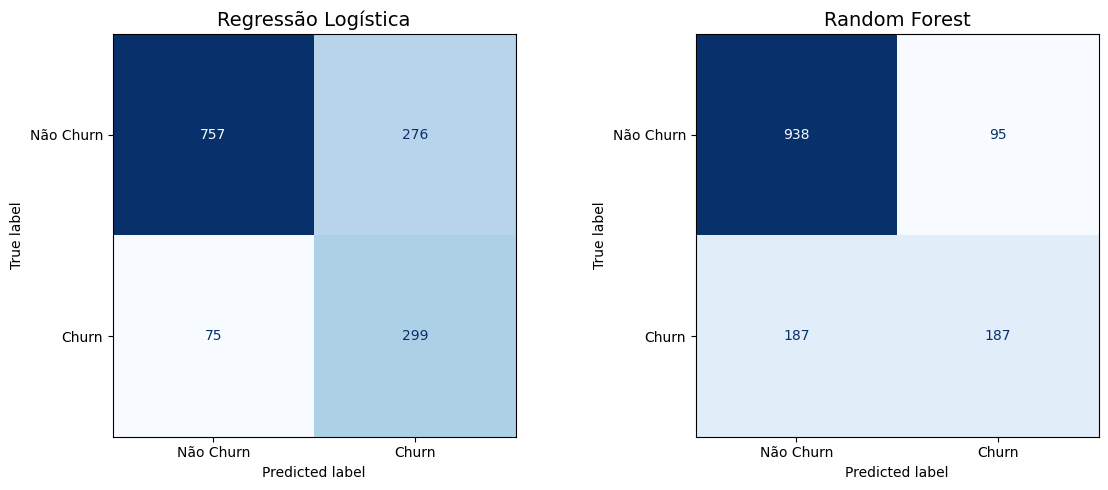

In [267]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nome, y_pred) in zip(axes, modelos.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Não Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome, fontsize=14)

plt.tight_layout()
plt.show()

In [268]:
print("Acurácia no TREINO:")
print(f"  Regressão Logística: {accuracy_score(y_train, modelo_lr.predict(X_train_scaled)):.4f}")
print(f"  Random Forest:       {accuracy_score(y_train, modelo_rf.predict(X_train)):.4f}")

print("\nAcurácia no TESTE:")
print(f"  Regressão Logística: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Random Forest:       {accuracy_score(y_test, y_pred_rf):.4f}")

Acurácia no TREINO:
  Regressão Logística: 0.7506
  Random Forest:       0.8416

Acurácia no TESTE:
  Regressão Logística: 0.7505
  Random Forest:       0.7996


# Análise de Importância das Variáveis

## Regressão Logística

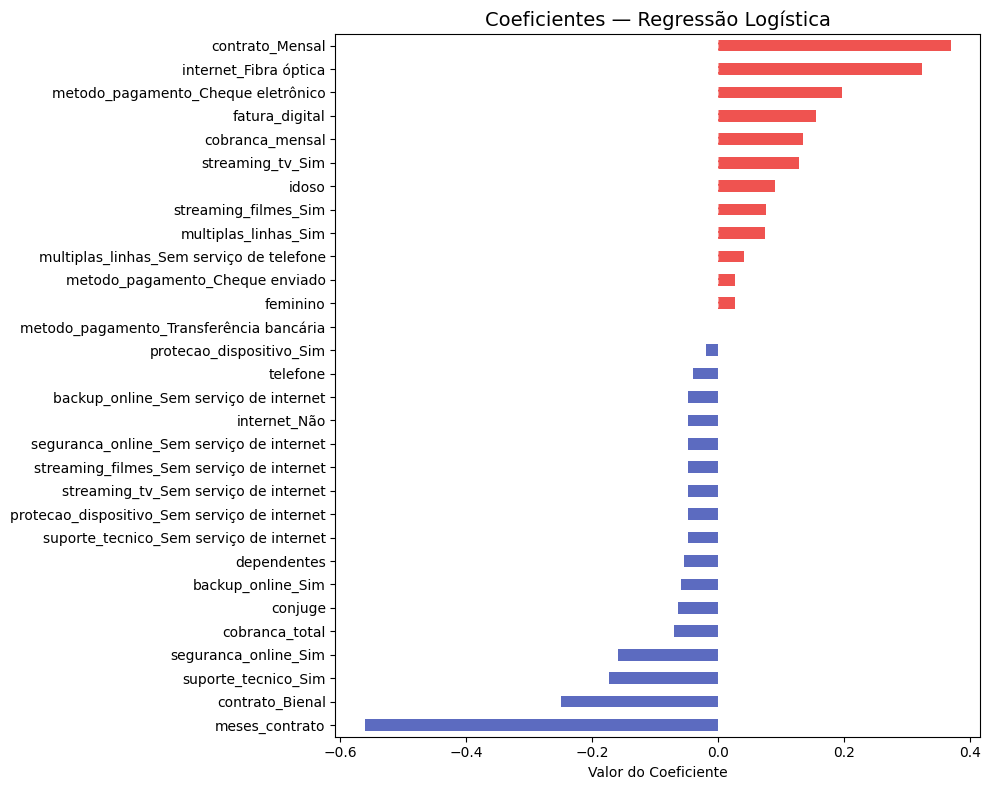

In [269]:
coeficientes = pd.Series(
    modelo_lr.coef_[0],
    index=X.columns
).sort_values()

plt.figure(figsize=(10, 8))
cores = ['#ef5350' if v > 0 else '#5c6bc0' for v in coeficientes]
coeficientes.plot(kind='barh', color=cores)
plt.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
plt.title('Coeficientes — Regressão Logística', fontsize=14)
plt.xlabel('Valor do Coeficiente')
plt.tight_layout()
plt.show()

## Random Forest

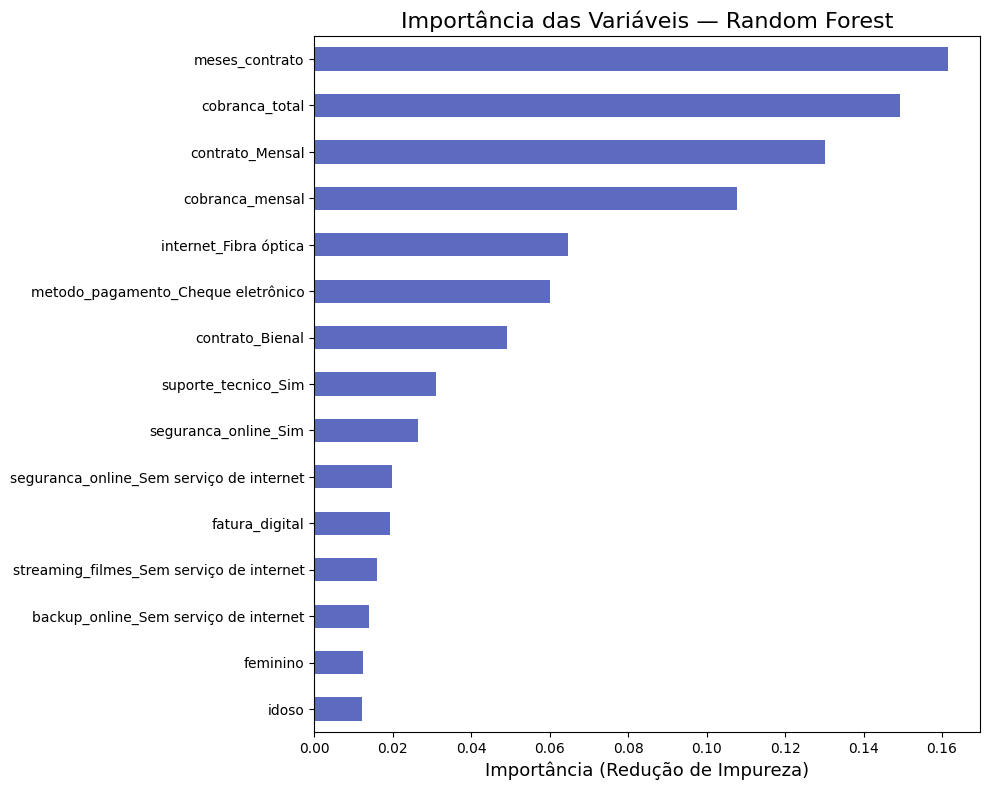

In [270]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values()

# Visualizar apenas o top 15
plt.figure(figsize=(10, 8))
importancias.tail(15).plot(kind='barh', color='#5c6bc0')
plt.title('Importância das Variáveis — Random Forest', fontsize=16)
plt.xlabel('Importância (Redução de Impureza)', fontsize=13)
plt.tight_layout()
plt.show()